### 目的
* 基于亚型间生物学差异特征，构建预后风险得分相关模型。

### 环境配置

In [1]:
set.seed(42)

target_dir = "C:\\Users\\wenfang\\Desktop\\TCGA-LUAD\\"
rna_meth_dir = paste0(target_dir, "result\\preprocess\\")
subtype_dir = paste0(target_dir, "result\\Cox_all_subtype\\")
result_dir = paste0(target_dir, "result\\split_degs_riskmodel\\")
if (!file.exists(result_dir)){
    dir.create(result_dir, recursive = TRUE)
}
print(result_dir)

[1] "C:\\Users\\wenfang\\Desktop\\TCGA-LUAD\\result\\split_degs_riskmodel\\"


### 数据分割

In [2]:
library(caret)

set.seed(123)

# 读取数值矩阵
rna_final <- read.table(paste0(subtype_dir,"rna_final.txt"), sep="\t", check.names = F)
meth_beta <- read.table(paste0(subtype_dir,"meth_final.txt"), sep="\t", check.names = F)

# 获取亚型间差异特征
rna_res_final <- read.table(paste0(subtype_dir, "rna_all.limma.C1.C2.features.txt"), sep="\t")
meth_res_final <- read.table(paste0(subtype_dir, "meth_all.limma.C1.C2.features.txt"), sep="\t")
rna_deg_1 <- subset(rna_res_final, adj.P.Val < 0.05 & abs(logFC) > 1)
meth_deg_0.1 <- subset(meth_res_final, adj.P.Val < 0.05 & abs(delta_beta) > 0.1)

# 划分训练集和测试集
surv_final <- read.table(paste0(subtype_dir, "surv_final.txt"), header=T, sep="\t")
train_idx <- createDataPartition(surv_final$OS, p = 0.7, times= 1, list=FALSE) 

# 训练集
train_rna <- t(rna_final)[train_idx, rna_deg_1$Gene]
train_beta <- t(meth_beta)[train_idx, meth_deg_0.1$Gene]
train_meth_M <- log2( train_beta / (1 - train_beta + 1e-8))
train_y <- surv_final[train_idx,]

# 测试集
test_rna <- t(rna_final)[-train_idx, rna_deg_1$Gene]
test_beta <- t(meth_beta)[-train_idx, meth_deg_0.1$Gene]
test_meth_M <- log2( test_beta / (1 - test_beta + 1e-8))
test_y <- surv_final[-train_idx,]

# 保存数据
write.table(train_rna, paste0(result_dir,"train_rna.txt"), sep="\t")
write.table(train_beta, paste0(result_dir,"train_beta.txt"), sep="\t")
write.table(test_rna, paste0(result_dir,"test_rna.txt"), sep="\t")
write.table(test_beta, paste0(result_dir,"test_beta.txt"), sep="\t")
write.table(train_y, paste0(result_dir,"train_y.txt"), sep="\t")
write.table(test_y, paste0(result_dir,"test_y.txt"), sep="\t")

Warning message:
"package 'caret' was built under R version 4.5.3"
Loading required package: ggplot2

Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Loading required package: lattice

Warning message:
"package 'lattice' was built under R version 4.5.3"


### 单因素Cox回归

In [3]:
library(survival)

cox_filter <- function(mat, surv_df){
    
    cox_full_result <- data.frame()
    
    # 批量单因素Cox
    cox_res <- lapply(colnames(mat), function(feature_name) {
        df <- data.frame(
                time = surv_df$OS.time,
                status = surv_df$OS,
                feature = mat[,feature_name]
            )
        
        tryCatch({
            withCallingHandlers({
          
                cx <- coxph(Surv(time, status) ~ feature, data=df)  
                cox_sum <- summary(cx)
            
                hr <- cox_sum$coefficients[,"exp(coef)"]        # 风险比HR
                ci_lower <- cox_sum$conf.int[,"lower .95"]      # 95%CI下限
                ci_upper <- cox_sum$conf.int[,"upper .95"]      # 95%CI上限
                pval <- cox_sum$coefficients[,"Pr(>|z|)"]       # P值

                data.frame(
                  Feature = feature_name,
                  HR = round(hr, 4),
                  HR_95CI_L = round(ci_lower, 4),
                  HR_95CI_U = round(ci_upper, 4),
                  Pvalue = signif(pval, 4)
                )
            }, 
            warning = function(w) {
                if (grepl("Loglik converged before variable  1 ; coefficient may be infinite. ", w$message)) {
                    stop("Perfect separation: ", w$message)
                } else {
                    warning(w)
                    return(NULL)
                }
            })
        },
        error=function(e){
            message("跳过异常特征: ", feature_name, " | 错误: ", e$message)
            return(NULL)
        })
    })

    cox_full_result <- do.call(rbind, cox_res)
    return(cox_full_result)
}

Warning message:
"package 'survival' was built under R version 4.5.3"

Attaching package: 'survival'


The following object is masked from 'package:caret':

    cluster




* 转录组

In [4]:
# 单因素cox回归
rna_cox_result <- cox_filter(train_rna, train_y)

# p<0.05生存显著相关
rna_sig_features = rna_cox_result$Feature[rna_cox_result$Pvalue < 0.05]
rna_deg_cox = train_rna[,rna_sig_features]

cat("显著预后特征(p<0.05):", length(rna_sig_features),"\n")
print(head(rna_cox_result))
#print(head(cox_result %>% filter(Pvalue<0.05), 10))

# p<0.01生存显著相关
rna_sig_features_0.01 = rna_cox_result$Feature[rna_cox_result$Pvalue < 0.01]
rna_deg_cox_0.01 = train_rna[,rna_sig_features_0.01]

cat("\n显著预后特征(p<0.01):", length(rna_sig_features_0.01),"\n")

# 保存特征
write.table(rna_cox_result, paste0(result_dir,"train_rna_cox.sig.all.features.txt"), sep="\t")
write.table(rna_deg_cox, paste0(result_dir,"train_rna_cox.sig.0.05.features.txt"), sep="\t")
write.table(rna_deg_cox_0.01, paste0(result_dir,"train_rna_cox.sig.0.01.features.txt"), sep="\t")

显著预后特征(p<0.05): 586 
  Feature     HR HR_95CI_L HR_95CI_U    Pvalue
1   SUSD2 0.8865    0.8126    0.9673 6.751e-03
2   CENPA 1.2234    1.0810    1.3846 1.403e-03
3    TPX2 1.3109    1.1427    1.5038 1.119e-04
4   HJURP 1.3318    1.1585    1.5311 5.622e-05
5  FAM83D 1.2114    1.0414    1.4092 1.292e-02
6    NEK2 1.2827    1.1193    1.4699 3.420e-04

显著预后特征(p<0.01): 341 


* 甲基化

In [16]:
# 单因素cox回归
meth_cox_result <- cox_filter(train_meth_M, train_y)

# p<0.05生存显著相关
meth_sig_features = meth_cox_result$Feature[meth_cox_result$Pvalue < 0.05]
meth_deg_cox = train_beta[,meth_sig_features]

cat("显著预后特征(p<0.05):", length(meth_sig_features),"\n")
print(head(meth_cox_result))
#print(head(cox_result %>% filter(Pvalue<0.05), 10))

# p<0.01生存显著相关
meth_sig_features_0.01 = meth_cox_result$Feature[meth_cox_result$Pvalue < 0.01]
meth_deg_cox_0.01 = train_beta[,meth_sig_features_0.01]

cat("\n显著预后特征(p<0.01):", length(meth_sig_features_0.01),"\n")

# 保存特征
write.table(meth_cox_result, paste0(result_dir,"train_meth_cox.sig.all.features.txt"), sep="\t")
write.table(meth_deg_cox, paste0(result_dir,"train_meth_cox.sig.0.05.features.txt"), sep="\t")
write.table(meth_deg_cox_0.01, paste0(result_dir,"train_meth_cox.sig.0.01.features.txt"), sep="\t")

显著预后特征(p<0.05): 15 
  Feature     HR HR_95CI_L HR_95CI_U  Pvalue
1 DEFB125 0.8628    0.7113    1.0465 0.13400
2    AQP1 1.2692    0.9074    1.7752 0.16380
3    CTSG 0.8051    0.6034    1.0742 0.14070
4   CCL11 0.7720    0.6060    0.9835 0.03619
5  CHRNA6 0.8321    0.6342    1.0918 0.18480
6    CCL7 0.8438    0.7165    0.9936 0.04166

显著预后特征(p<0.01): 2 


#### 因甲基化差异特征太少，无法分别构建单组学风险评分模型，故考虑合并转录组差异特征+甲基化差异特征，再进行Lasso-cox

In [6]:
library("glmnet")

rna_scaled <- scale(rna_deg_cox)
rna_mean <- attr(rna_scaled, "scaled:center") 
rna_sd  <- attr(rna_scaled, "scaled:scale")  

meth_M_deg_cox <- log2( meth_deg_cox / (1 - meth_deg_cox + 1e-8))
meth_scaled <- scale(meth_M_deg_cox)
meth_mean <- attr(meth_scaled, "scaled:center") 
meth_sd  <- attr(meth_scaled, "scaled:scale")   

combine_rna_meth_M <- cbind(rna_scaled, meth_scaled)
colnames(combine_rna_meth_M) <- c(paste0(colnames(rna_scaled),"_rna"), paste0(colnames(meth_scaled), "_meth"))

set.seed(430)

x <- combine_rna_meth_M
y <- Surv(train_y$OS.time, train_y$OS)

# Perform cross-validation to determine optimal lambda
cvfit <- tryCatch({
        suppressWarnings(
            cvfit <- cv.glmnet(x, y, family = "cox", alpha = 1, nfolds = 10, maxit = 10000)
            )
    },error=function(e) NULL)

if(is.null(cvfit)) next

# Plot coefficient paths versus log(lambda)
pdf(paste0(result_dir,"train_rna_meth_deg_cox_0.05.all.C1.C2.lambda.pdf"))
plot(cvfit$glmnet.fit, xvar = "lambda", label = TRUE)
dev.off()

# Plot cross-validation curve
pdf(paste0(result_dir,"train_rna_meth_deg_cox_0.05.all.C1.C2.cvfit.pdf"))
plot(cvfit)
abline(v = log(c(cvfit$lambda.min, cvfit$lambda.1se)), lty = "dashed", col = "red")
dev.off()

# Extract coefficients at lambda.min and features
coef_min <- coef(cvfit, s = "lambda.min")
index <- which(coef_min != 0)
select_features <- rownames(coef_min)[index]
features_coef <- coef_min[index]
lasso_feature_coef = data.frame(Feature = select_features, Coef = features_coef, row.names = NULL)
print("Lasso-Cox筛选后的特征集系数:")
print(lasso_feature_coef)

Warning message:
"package 'glmnet' was built under R version 4.5.3"
Loading required package: Matrix

Warning message:
"package 'Matrix' was built under R version 4.5.3"
Loaded glmnet 4.1-10



agg_record_9710527b5a83 
                      2

agg_record_9710527b5a83 
                      2

[1] "Lasso-Cox筛选后的特征集系数:"
      Feature          Coef
1    ANLN_rna  8.906799e-02
2   GPD1L_rna -3.015662e-02
3    CAV3_rna -6.742171e-04
4   ERO1L_rna  1.322775e-02
5    GNG7_rna -2.978209e-06
6 HMGCLL1_rna -2.095838e-02
7    IRX5_rna -1.080581e-01
8   ABCC2_rna  4.599908e-02


In [13]:
# step多因素Cox
lasso_cox_features_matrix <- cbind(train_y[, c("OS.time", "OS")], combine_rna_meth_M[,select_features])
full_model <- coxph(Surv(OS.time, OS) ~., data = lasso_cox_features_matrix)

full_model_features <- names(coef(full_model))
full_model_coef <- coef(full_model)
pval <- summary(full_model)$coefficients[,"Pr(>|z|)"]
full_model_df <- data.frame(Feature = final_features, Coef = final_coef, Pval = pval, row.names=NULL)
print(full_model_df)

# 双向逐步回归（基于AIC）
step_model <- step(full_model, direction = "both", trace=FALSE)

# 提取最终保留特征
step_features <- names(coef(step_model))
print(summary(step_model))

# 提取P< 0.05最终模型的特征
step_summary <- summary(step_model)
step_pvalues <- step_summary$coefficients[, "Pr(>|z|)"]

final_features <- names(step_pvalues[step_pvalues < 0.05])
print(final_features)

   Feature        Coef       Pval
1 IRX5_rna  0.12621806 0.36867301
2 IRX5_rna -0.01220210 0.92203925
3 IRX5_rna -0.17977878 0.19700759
4 IRX5_rna  0.14776893 0.20390361
5 IRX5_rna -0.04333499 0.71726347
6 IRX5_rna -0.14780378 0.15338816
7 IRX5_rna -0.22799061 0.06198853
8 IRX5_rna  0.14983808 0.09134934
Call:
coxph(formula = Surv(OS.time, OS) ~ CAV3_rna + ERO1L_rna + HMGCLL1_rna + 
    IRX5_rna + ABCC2_rna, data = lasso_cox_features_matrix)

  n= 310, number of events= 108 

                coef exp(coef) se(coef)      z Pr(>|z|)   
CAV3_rna    -0.21690   0.80501  0.13509 -1.606  0.10836   
ERO1L_rna    0.20343   1.22560  0.10471  1.943  0.05205 . 
HMGCLL1_rna -0.16501   0.84788  0.10031 -1.645  0.09995 . 
IRX5_rna    -0.28066   0.75528  0.09413 -2.982  0.00287 **
ABCC2_rna    0.14852   1.16012  0.08658  1.715  0.08628 . 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

            exp(coef) exp(-coef) lower .95 upper .95
CAV3_rna       0.8050     1.2422    0.6178  

#### 因step多因素Cox只剩一个特征，而且将8个特征重新拟合多因素cox， 发现都不显著，故最终选择Lasso-Cox结果用于建模

In [15]:
library("survival")
library("survminer")

# 提取特征在训练集和测试集中的矩阵
gene_names <- gsub("_rna$", "", select_features)
train_matrix <- rna_scaled[, gene_names, drop = FALSE]
test_matrix <- scale(test_rna[,gene_names], center = rna_mean[gene_names], scale = rna_sd[gene_names])

# 风险评分公式
cat("风险评分公式 = ")
for (i in 1:length(features_coef)) {
    cat(sprintf(" + (%.4f) x %s\n", features_coef[i], select_features[i]))
}

write.table(lasso_feature_coef, paste0(result_dir,"train_lasso_feature_coef.txt"), sep = "\t", quote = FALSE, row.names = FALSE, col.names = TRUE)

# 计算风险评分
train_risk <- as.vector(as.matrix(train_matrix) %*% features_coef)
test_risk  <- as.vector(as.matrix(test_matrix) %*% features_coef)

风险评分公式 =  + (0.0891) x ANLN_rna
 + (-0.0302) x GPD1L_rna
 + (-0.0007) x CAV3_rna
 + (0.0132) x ERO1L_rna
 + (-0.0000) x GNG7_rna
 + (-0.0210) x HMGCLL1_rna
 + (-0.1081) x IRX5_rna
 + (0.0460) x ABCC2_rna


* 高低风险分层——optimal cutoff value determined using the surv_cutpoint()

Ignoring unknown labels:
• colour : "Risk"
Ignoring unknown labels:
• colour : "Risk"


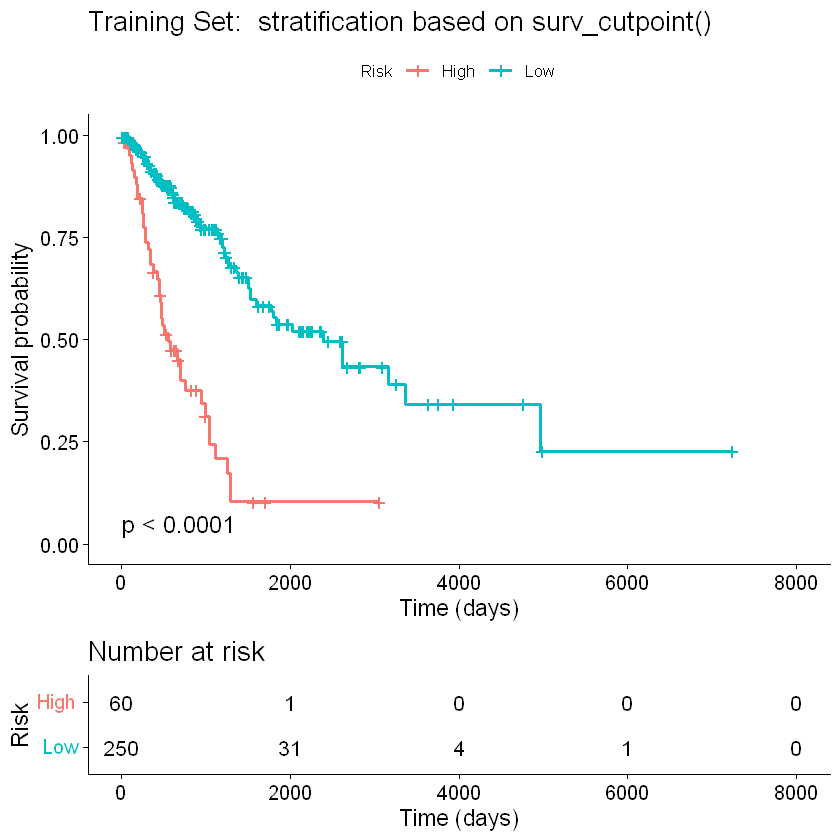

Ignoring unknown labels:
• colour : "Risk"


agg_record_9710731fee2 
                     2

Ignoring unknown labels:
• colour : "Risk"


agg_record_9710731fee2 
                     2

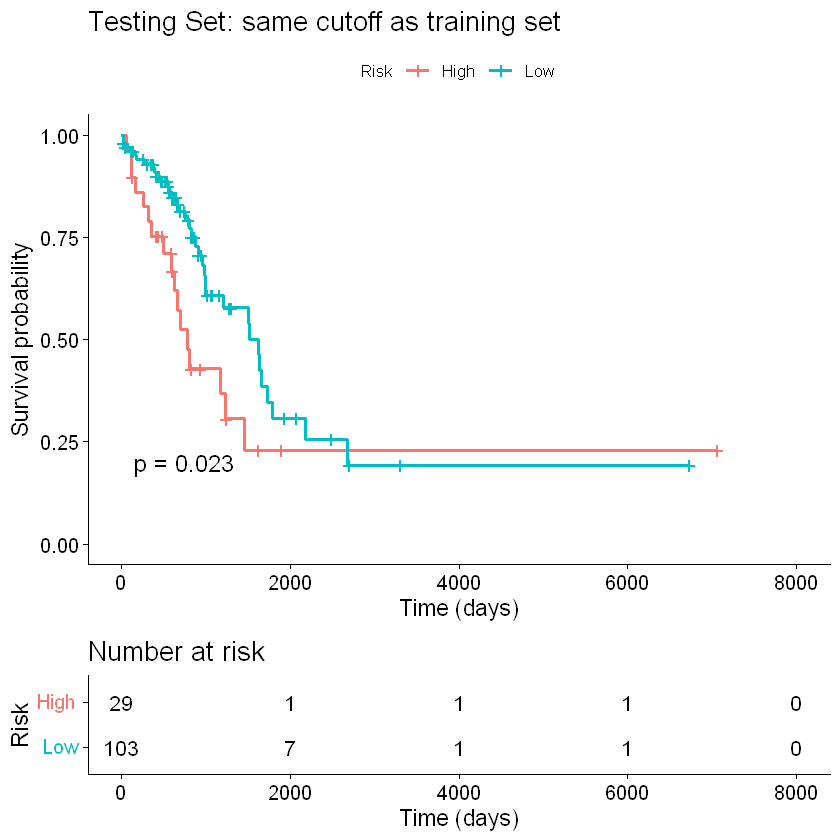

In [27]:
# KM 生存曲线
# 训练集
train_df <- data.frame(
    time = train_y$OS.time,
    event = train_y$OS,
    risk = train_risk
)
cutoff <- surv_cutpoint(train_df, time = "time", event = "event",variables="risk")

best_threshold <- summary(cutoff)$cutpoint
train_group_opt <- ifelse(train_risk > best_threshold, "High", "Low")
test_group_opt  <- ifelse(test_risk > best_threshold, "High", "Low")

fit_train_opt <- survfit(Surv(OS.time, OS) ~ train_group_opt, data = train_y[,c("OS.time", "OS")])
p_train_opt <- ggsurvplot(fit_train_opt, data = train_y[,c("OS.time", "OS")], pval = TRUE,
                       title = "Training Set:  stratification based on surv_cutpoint()",
                       xlab = "Time (days)", legend.title = "Risk",
                       legend.labs = c("High", "Low"),
                       pval.coord = c(0, 0.05),
                       risk.table = TRUE)
print(p_train_opt)

# 测试集
fit_test_opt <- survfit(Surv(OS.time, OS) ~ test_group_opt, data = test_y[,c("OS.time", "OS")])
p_test_opt <- ggsurvplot(fit_test_opt, data = test_y[,c("OS.time", "OS")], pval = TRUE,
                      title = "Testing Set: same cutoff as training set",
                      xlab = "Time (days)", legend.title = "Risk",
                      legend.labs = c("High", "Low"),
                      risk.table = TRUE)
print(p_test_opt)

pdf(paste0(result_dir, "train.KM_plot.pdf"), width= 10 , height= 8)
print(p_train_opt)
dev.off()

pdf(paste0(result_dir, "test.KM_plot.pdf"), width= 10 , height= 8)
print(p_test_opt)
dev.off()

In [57]:
# 保存风险评分结果
train_risk_df <- data.frame(
    sample_id = train_y$sample,
    OS.time = train_y$OS.time,
    OS = train_y$OS,
    risk_score = train_risk,
    risk_group = train_group
)

test_risk_df <- data.frame(
    sample_id = test_y$sample,
    OS.time = test_y$OS.time,
    OS = test_y$OS,
    risk_score = test_risk,
    risk_group = test_group
)

write.table(train_risk_df, paste0(result_dir,"train_risk_df.txt"), sep="\t")
write.table(test_risk_df, paste0(result_dir,"test_risk_df.txt"), sep="\t")

In [29]:
# 保存训练集均值和标准差，风险分层阈值
imp_df <- data.frame(
    train_mean = rna_mean,
    train_sd = rna_sd,
    train_cutoff = best_threshold
)
write.table(imp_df, paste0(result_dir,"train.mean.sd.surv_cutpoint.cutoff.imp_df.txt"), sep="\t")

* 时间依赖ROC

In [30]:
# 时间相关ROC
library(timeROC)

# 训练集
roc_train <- timeROC(T = train_y$OS.time, delta = train_y$OS, marker = train_risk, cause = 1, times = c(365, 1095, 1825), iid = TRUE)

# 测试集
roc_test <- timeROC(T = test_y$OS.time, delta = test_y$OS, marker = test_risk, cause = 1, times = c(365, 1095, 1825), iid = TRUE)

# 汇总
cat("训练集AUC:", roc_train$AUC, "\n")
cat("测试集AUC:", roc_test$AUC, "\n")

# 绘图
pdf(paste0(result_dir, "test.timeROC.pdf"), width= 10 , height= 8)
plot(roc_test, time = 365, col = "red", lwd = 2, title="Time-dependent ROC")
plot(roc_test, time = 1095, col = "blue", lwd = 2, add = TRUE)
plot(roc_test, time = 1825, col = "green", lwd = 2, add = TRUE)
legend("bottomright", legend = c("1-year", "3-year", "5-year"), col = c("red", "blue", "green"), lwd = 2)
dev.off()

Warning message:
"package 'timeROC' was built under R version 4.5.3"


训练集AUC: 0.6850104 0.7106192 0.6981853 
测试集AUC: 0.7599504 0.6001027 0.5310943 


agg_record_971031a970ce 
                      2

* C-index

In [40]:
# C-index
train_cindex <- summary(coxph(Surv(train_y$OS.time, train_y$OS) ~ train_risk))$concordance[1]
test_cindex <- summary(coxph(Surv(test_y$OS.time, test_y$OS) ~ test_risk))$concordance[1]
cat(sprintf("训练集C-index: %.3f\n", train_cindex))
cat(sprintf("测试集C-index: %.3f\n", test_cindex))

训练集C-index: 0.665
测试集C-index: 0.680


#### 功能富集分析
* 对转录组 DEG 做 GSEA/GO/KEGG，验证两个亚型的生物学差异（比如 C1 富集脂肪酸代谢，C2 富集增殖、EMT、氧化应激，贴合 EC 衰老背景）

In [21]:
library(clusterProfiler)
gene_list <- rna_deg$logFC
print(head(gene_list))
names(gene_list) <- rownames(rna_deg)
gsea_res <- gseKEGG(gene_list, organism="hsa", pvalueCutoff=0.05)

Warning message:
"package 'clusterProfiler' was built under R version 4.5.3"


clusterProfiler v4.18.4 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

S Xu, E Hu, Y Cai, Z Xie, X Luo, L Zhan, W Tang, Q Wang, B Liu, R Wang,
W Xie, T Wu, L Xie, G Yu. Using clusterProfiler to characterize
multiomics data. Nature Protocols. 2024, 19(11):3292-3320


Attaching package: 'clusterProfiler'


The following object is masked from 'package:stats':

    filter




[1] -1.785043  1.380244  1.024014  1.031742


Reading KEGG annotation online: "https://rest.kegg.jp/link/hsa/pathway"...

Reading KEGG annotation online: "https://rest.kegg.jp/list/pathway/hsa"...



ERROR: Error in GSEA_internal(geneList = geneList, exponent = exponent, minGSSize = minGSSize, : geneList should be a decreasing sorted vector...
